# NFL Draft Analysis: WR Draft Capital vs. NFL Production
**Goal:** Analyze the relationship between draft position and subsequent NFL performance for wide receivers.

**Data Sources Needed:**
1. Draft data (2020-2023 WRs) - Pick number, team, college
2. Combine/pro-day data - Athletic testing
3. NFL production data - Receiving yards, TDs, PFF grades, etc.
4. College Receiving Stats (Top 300 in receiving yards by year)

NOTES
1️⃣ Executive Summary (Very Important)

Start with 5–7 bullet points:

Early first-round WRs outperform mid-round WRs by X% in first 3 seasons

After round 3, performance variance increases significantly

Draft capital explains only X% of performance variance

Recommendation: teams may overvalue early WR picks relative to expected output

This shows you can synthesize insight.


2️⃣ Clear Business-Style Question

Frame it as:

“If draft capital is an investment, what is the expected return by draft position?”

Now you’re thinking analytically.


3️⃣ Methodology Section

Explain:

Data sources (NFL draft history + NextGen stats)

Cleaning steps

How you defined “performance”

Statistical techniques used

This shows rigor.


4️⃣ SQL + Python Separation

Even if you’re using Jupyter:

Use SQL for querying and aggregation

Use Python for modeling and visualization

Employers LOVE seeing SQL competence.


5️⃣ Visualizations

Use:

Draft round vs average yards per season

Career longevity by round

Scatter plot: draft pick vs production

Regression line

Boxplots

Make them clean and labeled professionally.


6️⃣ Interpretation Section

This is where most candidates fail.

Don’t just show charts.

Explain:

Why patterns might exist

Confounding factors

Limitations of dataset

What additional data would improve model

That shows maturity.



How To Display It Properly
Option A (Best): Portfolio Website

Create a simple site (GitHub Pages or Notion) with:

Project title

Summary

Problem statement

Key charts

GitHub link

PDF-style report



📊 1. Contract Value Efficiency

“Are WRs on rookie contracts outperforming veterans relative to cap hit?”

Now you’re talking ROI analysis.

📈 2. Predicting Breakout Seasons

Using draft position + college stats + early career metrics to predict Year 3 breakout probability.

That’s predictive modeling.

🧮 3. NextGen Separation vs Production

Does separation correlate with yards?
Are certain archetypes undervalued?

That shows correlation analysis and regression.

📉 4. Team Draft Strategy Evaluation

Which franchises consistently outperform draft expectation at WR?

That shows benchmarking.

In [2]:
# Import essential libraries for data analysis
import matplotlib.pyplot as plt
import pandas as pd  # For data manipulation (think: Excel in Python)
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt  # For basic plotting
import seaborn as sns  # For nicer visualizations
import warnings
warnings.filterwarnings('ignore')  # Clean up output by hiding warnings

# Set up visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")

✅ Libraries imported successfully!
Pandas version: 3.0.0


Analysis #1: Hit Rate By Round

I have a tiered system to determine if a receiver is a hit and to what extent that receiver has hit. Below I have the tiers:

Elite:	1,200+ yard season OR 2x 1,000+ yard seasons	Top 12 WR
Hit:	1,000+ yard season OR 2x 700+ yard seasons	Solid starter
Role:	500+ yard season OR 30+ YPG career	Contributes
Bust:	Never hit 500 yards in a season	Didn't work out


In [3]:
import sqlite3
import pandas as pd
import os


if os.path.exists('wr_nfl_draft.db'):
    os.remove('wr_nfl_draft.db')
    print("🗑️ Deleted old database file")


# Connect to SQLite
conn = sqlite3.connect('wr_nfl_draft.db')

# Read the CSV
df = pd.read_csv('data/NFLDraftPositionWR2011-2025.csv')
print(f"✅ Loaded CSV: {len(df)} rows")
print(f"   Columns: {list(df.columns)}")

# Load CSV into SQLite as a table
df.to_sql('wr_draft_picks', conn, if_exists='replace', index=False)
print("Loaded into SQLite as table 'wr_draft_picks'")

cursor = conn.cursor()
#cursor.execute("SELECT COUNT(*) FROM wr_draft_picks")
cursor.execute("SELECT Name FROM wr_draft_picks WHERE Round = 1")
results = cursor.fetchall()
print("First 10")
for i, row in enumerate(results[:10]):
    print(f"{i+1}. {row[0]}")



conn.close()



🗑️ Deleted old database file
✅ Loaded CSV: 481 rows
   Columns: ['Year', 'No.', 'Round', 'Pick', 'Player', 'Name', 'Team', 'College']
Loaded into SQLite as table 'wr_draft_picks'
First 10
1. Travis Hunter
2. Tetairoa McMillan
3. Emeka Egbuka
4. Matthew Golden
5. Marvin Harrison
6. Malik Nabers
7. Rome Odunze
8. Brian Thomas
9. Xavier Worthy
10. Ricky Pearsall


In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('wr_nfl_draft.db')

nextgen_df = pd.read_csv('data/NextGenWRStats2018-2025.csv')

nextgen_df.to_sql('nextgen_stats', conn, if_exists='replace', index=False)


cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM nextgen_stats WHERE POS = 'WR'")
wr_count = cursor.fetchone()[0]
conn.close()



In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('wr_nfl_draft.db')

query = """
SELECT 
    NAME,
    COUNT(*) as seasons_800plus,
    SUM(YDS) as total_yards,
    AVG(YDS) as avg_yards_per_season
FROM nextgen_stats
WHERE POS = 'WR' 
    AND YDS >= 800
GROUP BY NAME
HAVING COUNT(*) >= 3
ORDER BY seasons_800plus DESC, total_yards DESC;
"""

results = pd.read_sql_query(query, conn)

print(f"🏈 WRs with 3+ seasons of 800+ yards (2018-2025): {len(results)}")
print("=" * 70)
print(results.to_string(index=False))
conn.close()

🏈 WRs with 3+ seasons of 800+ yards (2018-2025): 43
               NAME  seasons_800plus  total_yards  avg_yards_per_season
        Tyreek Hill                7         9322           1331.714286
      Davante Adams                7         9033           1290.428571
       Stefon Diggs                7         8532           1218.857143
         Mike Evans                7         8105           1157.857143
         A.J. Brown                7         8029           1147.000000
   Justin Jefferson                6         8480           1413.333333
        CeeDee Lamb                6         7416           1236.000000
         D.J. Moore                6         6747           1124.500000
       Amari Cooper                6         6583           1097.166667
     Terry McLaurin                6         6379           1063.166667
         DK Metcalf                6         6274           1045.666667
      Tyler Lockett                6         6178           1029.666667
       Chris

This next cell will help me determine how to qualify which receivers are elite, hits, or busts. I am going to get a distribution of receving yards to see what is considered average, above average, and below average.

Keep in mind, the NFL Next Gen Stats are for players targeted 45+ times, meaning that there will be "hidden" busts that who don't have any stats that show up. There also need to be a category for "too soon to tell"


Here are some key methods
1. NextGen Stats - Only 45+ targets
YES, this is actually a feature, not a bug. Here's why:

If a WR doesn't get 45 targets in a season, they're either:
Injured
Not good enough to get on the field
A rookie who hasn't earned trust yet

Rookies sometimes take time. A 2024 draftee with 40 targets in Year 1 might be fine. We'll handle this with "Too Soon" flags.

2. Start with 2018-2022 draftees
YES. Perfect logic:

Drafted 2018-2022 = have 3-7 NFL seasons

All their seasons (if productive) appear in NextGen

No data gaps

This gives us 5 draft classes to analyze. Enough for meaningful hit rates.



In [6]:
import sqlite3
import pandas as pd
import os

# Connect to database (will create if doesn't exist)
conn = sqlite3.connect('nfl_analytics.db')
print("✅ Connected to database")

# List of files to load
files = {
    'draft_picks': 'data/NFLDraftPositionWR2011-2025.csv',
    'nextgen': 'data/NextGenWRStats2018-2025.csv',
    'combine': 'data/NFLCombineStats2017-2025.csv',
    'college': 'data/CollegeReceivingStats2017-2025.csv'
}

# Load each file into SQLite
for table_name, file_path in files.items():
    try:
        df = pd.read_csv(file_path)
        df.to_sql(table_name, conn, if_exists='replace', index=False)
        print(f"✅ Loaded {table_name}: {len(df)} rows")
    except Exception as e:
        print(f"❌ Error loading {file_path}: {e}")

conn.close()
print("\n🔒 Connection closed")

✅ Connected to database
✅ Loaded draft_picks: 481 rows
✅ Loaded nextgen: 995 rows
✅ Loaded combine: 550 rows
✅ Loaded college: 2700 rows

🔒 Connection closed


Before deciding thresholds that make receivers elite, a hit, a role player, or a bust, I need to decide what those metrics are. To do so, I will run a distrubtion on yards and touchdowns of all receivers in the NextGen data. Because NextGen data has players with over 45 targets, all seasons with less than 45 targets will either be counted as a "lost season" and won't go towards the numbers.

In [7]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

# See yards distribution
query = """
SELECT 
    CASE 
        WHEN YDS >= 1200 THEN '1200+'
        WHEN YDS >= 800 THEN '800-1199'
        WHEN YDS >= 400 THEN '400-799'
        ELSE 'Under 400'
    END as yards_tier,
    COUNT(*) as seasons,
    COUNT(DISTINCT NAME) as players,
    ROUND(AVG(TD), 1) as avg_tds
FROM nextgen
WHERE POS = 'WR'
GROUP BY yards_tier
ORDER BY MIN(YDS);
"""

yards_dist = pd.read_sql_query(query, conn)
print("WR SEASONS BY YARDS TIER")
print("=" * 60)
print(yards_dist.to_string(index=False))

conn.close()

WR SEASONS BY YARDS TIER
yards_tier  seasons  players  avg_tds
 Under 400      111       95      1.9
   400-799      365      199      3.6
  800-1199      205       93      6.0
     1200+       64       40      9.3


Based on my findings, this is how I will determine certain tiers of receivers:

Elite:	    1,200+ yard season OR 10+ TDs	Only 40 players ever reached this
Hit:	    800+ yard season OR 6+ TDs	93 players, avg 6 TDs - clear starter level
Role:	    400+ yard season OR 3+ TDs	199 players, solid contributor
Bust:	    Never hit 400 yards OR never in NextGen	95 players had a sub-400 season
Too Early:  Players drafted from 2024 or 2025 draft who do not reach any tier

In [8]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

# Check the join with correct columns
query_check = """
SELECT 
    d.Name as draft_name,
    d.Year as draft_year,
    d.Round,
    n.NAME as nextgen_name,
    n.YEAR as nextgen_year,
    n.YDS,
    n.TD
FROM draft_picks d
LEFT JOIN nextgen n ON d.Name = n.NAME
WHERE d.Year BETWEEN 2017 AND 2025
    AND d.Name NOT LIKE '%pick%'
    AND d.Name NOT LIKE '%Pick%'
LIMIT 30;
"""

sample = pd.read_sql_query(query_check, conn)
print("🔍 SAMPLE OF JOIN RESULTS:")
print(sample.to_string())

# Count how many have matches
query_count = """
SELECT 
    COUNT(DISTINCT d.Name) as total_drafted,
    COUNT(DISTINCT n.NAME) as have_nextgen_data
FROM draft_picks d
LEFT JOIN nextgen n ON d.Name = n.NAME
WHERE d.Year BETWEEN 2017 AND 2025
    AND d.Name NOT LIKE '%pick%';
"""

counts = pd.read_sql_query(query_count, conn)
print("\n📊 MATCH STATS:")
print(counts)

conn.close()

🔍 SAMPLE OF JOIN RESULTS:
               draft_name  draft_year  Round       nextgen_name  nextgen_year     YDS   TD
0           Travis Hunter        2025      1      Travis Hunter        2025.0   298.0  1.0
1       Tetairoa McMillan        2025      1  Tetairoa McMillan        2025.0  1013.0  7.0
2            Emeka Egbuka        2025      1       Emeka Egbuka        2025.0   938.0  6.0
3          Matthew Golden        2025      1                NaN           NaN     NaN  NaN
4          Jayden Higgins        2025      2     Jayden Higgins        2025.0   525.0  6.0
5           Luther Burden        2025      2      Luther Burden        2025.0   652.0  2.0
6              Tre Harris        2025      2                NaN           NaN     NaN  NaN
7               Jack Bech        2025      2                NaN           NaN     NaN  NaN
8           Kyle Williams        2025      3                NaN           NaN     NaN  NaN
9            Isaac TeSlaa        2025      3                NaN 

In [9]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_tiers AS (
    -- First, classify each player's BEST season
    SELECT 
        n.NAME,
        MAX(CASE 
            WHEN n.YDS >= 1200 OR n.TD >= 10 THEN 'Elite'
            WHEN n.YDS >= 800 OR n.TD >= 6 THEN 'Hit'
            WHEN n.YDS >= 400 OR n.TD >= 3 THEN 'Role'
            ELSE 'Below Role'
        END) as peak_tier,
        MAX(n.YDS) as peak_yards,
        MAX(n.TD) as peak_tds,
        COUNT(DISTINCT n.YEAR) as seasons_in_nextgen
    FROM nextgen n
    WHERE n.POS = 'WR'
    GROUP BY n.NAME
),
drafted_players AS (
    -- Get all drafted WRs 2017-2025
    SELECT 
        d.Name as Player,
        d.Year as draft_year,
        d.Round,
        d.Pick,
        pt.peak_tier,
        pt.peak_yards,
        pt.peak_tds,
        pt.seasons_in_nextgen,
        -- Determine final tier with "Too Early" logic
        CASE 
            -- Too Early (2024-2025 draftees with no Elite/Hit yet)
            WHEN d.Year >= 2024 AND (pt.peak_tier IS NULL OR pt.peak_tier IN ('Below Role', 'Role')) THEN 'Too Early'
            -- Never appeared in NextGen = Bust
            WHEN pt.peak_tier IS NULL THEN 'Bust'
            -- Appeared but never hit Role = Bust
            WHEN pt.peak_tier = 'Below Role' THEN 'Bust'
            -- Everything else
            ELSE pt.peak_tier
        END as final_tier
    FROM draft_picks d
    LEFT JOIN player_tiers pt ON d.Name = pt.NAME
    WHERE d.Year BETWEEN 2017 AND 2025
        AND d.Name NOT LIKE '%pick%'
        AND d.Name NOT LIKE '%Pick%'
        AND d.Name NOT LIKE '%selection%'
        AND d.Name NOT LIKE '%Forfeit%'
)
-- Final summary by round
SELECT 
    Round,
    COUNT(*) as total_drafted,
    SUM(CASE WHEN final_tier = 'Elite' THEN 1 ELSE 0 END) as elite_count,
    SUM(CASE WHEN final_tier = 'Hit' THEN 1 ELSE 0 END) as hit_count,
    SUM(CASE WHEN final_tier = 'Role' THEN 1 ELSE 0 END) as role_count,
    SUM(CASE WHEN final_tier = 'Bust' THEN 1 ELSE 0 END) as bust_count,
    SUM(CASE WHEN final_tier = 'Too Early' THEN 1 ELSE 0 END) as too_early_count,
    -- Calculate percentages (excluding Too Early)
    ROUND(SUM(CASE WHEN final_tier IN ('Elite', 'Hit', 'Role') THEN 1 ELSE 0 END) * 100.0 / 
          NULLIF(SUM(CASE WHEN final_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as success_rate,
    ROUND(SUM(CASE WHEN final_tier = 'Elite' THEN 1 ELSE 0 END) * 100.0 / 
          NULLIF(SUM(CASE WHEN final_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as elite_rate
FROM drafted_players
GROUP BY Round
ORDER BY Round;
"""

# Execute and display
results = pd.read_sql_query(query, conn)

print("🏈 WR HIT RATE BY DRAFT ROUND (2017-2025)")
print("=" * 100)
print(results.to_string(index=False))

# Also show overall totals
print("\n" + "=" * 100)
print("📊 OVERALL SUMMARY")

total_players = results['total_drafted'].sum()
total_evaluated = total_players - results['too_early_count'].sum()
print(f"Total WRs drafted 2017-2025: {total_players}")
print(f"Evaluated (excluding Too Early): {total_evaluated}")
print(f"Too Early (2024-2025): {results['too_early_count'].sum()}")

conn.close()

🏈 WR HIT RATE BY DRAFT ROUND (2017-2025)
 Round  total_drafted  elite_count  hit_count  role_count  bust_count  too_early_count  success_rate  elite_rate
     1             39            1         11          17           2                8          93.5         3.2
     2             46            0          7          24           9                6          77.5         0.0
     3             44            0          2          16          16               10          52.9         0.0
     4             38            0          3           6          19               10          32.1         0.0
     5             35            0          1           9          19                6          34.5         0.0
     6             47            0          1          14          22               10          40.5         0.0
     7             42            0          0           5          27               10          15.6         0.0

📊 OVERALL SUMMARY
Total WRs drafted 2017-2025: 291
Eva

This method didn't work quite right, so we needed to measure numerically.

In [10]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_tiers AS (
    -- Use numeric scores for proper MAX comparison
    SELECT 
        n.NAME,
        MAX(CASE 
            WHEN n.YDS >= 1200 OR n.TD >= 10 THEN 4  -- Elite
            WHEN n.YDS >= 800 OR n.TD >= 6 THEN 3    -- Hit
            WHEN n.YDS >= 400 OR n.TD >= 3 THEN 2    -- Role
            ELSE 1                                    -- Below Role
        END) as tier_score,
        MAX(n.YDS) as peak_yards,
        MAX(n.TD) as peak_tds,
        COUNT(DISTINCT n.YEAR) as seasons_in_nextgen
    FROM nextgen n
    WHERE n.POS = 'WR'
    GROUP BY n.NAME
),
drafted_players AS (
    -- Get all drafted WRs 2017-2025
    SELECT 
        d.Name as Player,
        d.Year as draft_year,
        d.Round,
        d.Pick,
        CASE 
            WHEN pt.tier_score = 4 THEN 'Elite'
            WHEN pt.tier_score = 3 THEN 'Hit'
            WHEN pt.tier_score = 2 THEN 'Role'
            WHEN pt.tier_score = 1 THEN 'Below Role'
            ELSE NULL
        END as peak_tier,
        pt.peak_yards,
        pt.peak_tds,
        pt.seasons_in_nextgen,
        -- Determine final tier with "Too Early" logic
        CASE 
            -- Too Early (2024-2025 draftees not yet proven)
            WHEN d.Year >= 2024 AND (pt.tier_score IS NULL OR pt.tier_score <= 2) THEN 'Too Early'
            -- Never appeared in NextGen = Bust
            WHEN pt.tier_score IS NULL THEN 'Bust'
            -- Appeared but never hit Role = Bust
            WHEN pt.tier_score = 1 THEN 'Bust'
            -- Everything else - map numeric back to tier
            WHEN pt.tier_score = 4 THEN 'Elite'
            WHEN pt.tier_score = 3 THEN 'Hit'
            WHEN pt.tier_score = 2 THEN 'Role'
        END as final_tier
    FROM draft_picks d
    LEFT JOIN player_tiers pt ON d.Name = pt.NAME
    WHERE d.Year BETWEEN 2017 AND 2025
        AND d.Name NOT LIKE '%pick%'
        AND d.Name NOT LIKE '%Pick%'
        AND d.Name NOT LIKE '%selection%'
)
-- Final summary by round
SELECT 
    Round,
    COUNT(*) as total_drafted,
    SUM(CASE WHEN final_tier = 'Elite' THEN 1 ELSE 0 END) as elite_count,
    SUM(CASE WHEN final_tier = 'Hit' THEN 1 ELSE 0 END) as hit_count,
    SUM(CASE WHEN final_tier = 'Role' THEN 1 ELSE 0 END) as role_count,
    SUM(CASE WHEN final_tier = 'Bust' THEN 1 ELSE 0 END) as bust_count,
    SUM(CASE WHEN final_tier = 'Too Early' THEN 1 ELSE 0 END) as too_early_count,
    -- Calculate percentages (excluding Too Early)
    ROUND(SUM(CASE WHEN final_tier IN ('Elite', 'Hit', 'Role') THEN 1 ELSE 0 END) * 100.0 / 
          NULLIF(SUM(CASE WHEN final_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as success_rate,
    ROUND(SUM(CASE WHEN final_tier = 'Elite' THEN 1 ELSE 0 END) * 100.0 / 
          NULLIF(SUM(CASE WHEN final_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as elite_rate
FROM drafted_players
GROUP BY Round
ORDER BY Round;
"""

# Execute and display
results = pd.read_sql_query(query, conn)

print("WR HIT RATE BY DRAFT ROUND (2017-2025)")
print("=" * 100)
print(results.to_string(index=False))

# Also show overall totals
print("\n" + "=" * 100)
print("OVERALL SUMMARY")

total_players = results['total_drafted'].sum()
total_evaluated = total_players - results['too_early_count'].sum()
print(f"Total WRs drafted 2017-2025: {total_players}")
print(f"Evaluated (excluding Too Early): {total_evaluated}")
print(f"Too Early (2024-2025): {results['too_early_count'].sum()}")

conn.close()

WR HIT RATE BY DRAFT ROUND (2017-2025)
 Round  total_drafted  elite_count  hit_count  role_count  bust_count  too_early_count  success_rate  elite_rate
     1             39           16         14           3           2                4          94.3        45.7
     2             46            5         16          10           9                6          77.5        12.5
     3             44            5          6           7          16               10          52.9        14.7
     4             38            1          3           5          19               10          32.1         3.6
     5             35            1          6           3          19                6          34.5         3.4
     6             47            0          5          10          22               10          40.5         0.0
     7             42            0          2           3          27               10          15.6         0.0

OVERALL SUMMARY
Total WRs drafted 2017-2025: 291
Evaluat

In order to make sure this data makes sense, I wanted to manually check myself. So I printed out all the receivers drafted in round five to make sure there was truly only one elite player drafted within the past 8 years in that round. 

In [11]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
SELECT 
    Year,
    Round,
    Pick,
    Name as Player,
    Team,
    College
FROM draft_picks
WHERE Year BETWEEN 2017 AND 2025
    AND Round = 5
    AND Name NOT LIKE '%pick%'
    AND Name NOT LIKE '%Pick%'
    AND Name NOT LIKE '%selection%'
ORDER BY Year, Pick;
"""

fifth_round = pd.read_sql_query(query, conn)

print("🏈 5TH ROUND WR DRAFT PICKS (2017-2025)")
print("=" * 80)
print(fifth_round.to_string(index=False))
print(f"\n📊 Total 5th round WRs: {len(fifth_round)}")

conn.close()

🏈 5TH ROUND WR DRAFT PICKS (2017-2025)
 Year  Round  Pick                   Player       Team        College
 2017      5    22           Shelton Gibson     Eagles  West Virginia
 2017      5    27             Rodney Adams    Vikings  South Florida
 2017      5    29          Isaiah McKenzie    Broncos        Georgia
 2017      5    32          DeAngelo Yancey    Packers         Purdue
 2017      5    34             Trent Taylor      49ers Louisiana Tech
 2018      5     7            Justin Watson Buccaneers   Pennsylvania
 2018      5    22         Daurice Fountain      Colts  Northern Iowa
 2018      5    25            Jordan Lasley     Ravens           UCLA
 2018      5    37 Marquez Valdes-Scantling    Packers  South Florida
 2019      5    11           Hunter Renfrow    Raiders        Clemson
 2019      5    26                 EJ Speed      Colts Tarleton State
 2019      5    33           Darius Slayton     Giants         Auburn
 2020      5     5                 Joe Reed   Charg

I wanted to do one more check just to make sure, so I wrote a query to check the total number of "Elite" receivers to make sure we got the right number.

In [12]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')
query = """
    SELECT 
        n.NAME,
        MAX(CASE 
            WHEN n.YDS >= 1200 OR n.TD >= 10 THEN 4  -- Elite
            WHEN n.YDS >= 800 OR n.TD >= 6 THEN 3    -- Hit
            WHEN n.YDS >= 400 OR n.TD >= 3 THEN 2    -- Role
            ELSE 1                                    -- Below Role
        END) as tier_score,
        MAX(n.YDS) as peak_yards,
        MAX(n.TD) as peak_tds,
        COUNT(DISTINCT n.YEAR) as seasons_in_nextgen, 
        d.Year as DraftYear
    FROM nextgen n
    LEFT JOIN draft_picks d ON d.Name = n.Name
    WHERE n.POS = 'WR' AND d.Year BETWEEN 2017 AND 2025
    GROUP BY n.NAME
    ORDER BY 2 DESC, 6 DESC
"""

'''
query = """
SELECT 
    n.Name as Player,
    MAX(n.YDS) as Max_Yards,
    MAX(n.TD) as Max_TD
FROM nextgen n
LEFT JOIN draft_picks d
ON   n.Name = d.Name
WHERE d.Year BETWEEN 2017 AND 2025
AND n.POS = 'WR'
AND (n.YDS >= 1200 OR n.TD >= 10)
GROUP BY Player
ORDER BY 2 DESC, 3
"""
'''
checking = pd.read_sql_query(query, conn)

#print("YDS and TDs for all players")
#print("=" * 80)
print(checking.to_string(index=False))
#print(f"\n Total Elite WRs: {len(checking)}")

conn.close()

                    NAME  tier_score  peak_yards  peak_tds  seasons_in_nextgen  DraftYear
            Brian Thomas           4        1282        10                   2       2024
            Malik Nabers           4        1204         7                   1       2024
      Jaxon Smith-Njigba           4        1793        10                   3       2023
          Jordan Addison           4         911        10                   3       2023
              Puka Nacua           4        1715        10                   3       2023
             Zay Flowers           4        1211         5                   3       2023
            Drake London           4        1271         9                   4       2022
          George Pickens           4        1429         9                   4       2022
       Amon-Ra St. Brown           4        1515        12                   5       2021
           DeVonta Smith           4        1210         8                   5       2021
          

Now that we know our findings match our data, we wanted to take a deeper and more analytical dive, counting the number of seasons each player was considered elite, a hit, a role player, or a bust. In this next cell, we will count the number of seasons where each player has an elite yards and/or td season, as well as hit seasons and role seasons. From there, we will determine how many seasons of elite play it will take to categorize a player as elite, etc. We are going for more consistency from players rather than just a peak season.

Here is our new criteria:

ELITE = 2+ seasons with elite YDS (1200+), 
        or 2+ seasons with elite TDs (10+), 
        or 1 season with elite YDS AND 1 season of elite TDs

HIT =   2+ seasons with hit YDS (800-1199), 
        or 2+ seasons with hit TDs (6-9), 
        or 1 season with hit YDS AND 1 season of hit TDs

ROLE =  2+ seasons with role YDS (400-799), 
        or 2+ seasons with role TDs (3-5), 
        or 1 season with role YDS AND 1 season of role TDs

Recent Draftees (2024-2025):

Players drafted in 2024:
ELITE = 2+ Elite YDS OR tds, 
        or 1 Elite YDS AND 1 Elite tds

HIT =   1 Elite YDS AND 1 Hit YDS, 
        1 Elite TDs AND 1 Hit TDs, 
        1 Elite YDS AND 1 Hit TDs,
        1 Elite TDs and 1 Hit YDS,

Too Soon = 1 Hit yds OR tds (or anything below)

Players drafted in 2025 
ELITE = Elite YDS AND TDs
HIT =   Elite YDS AND Hit TDs, 
        or Hit YDS AND Elite TDs
Too Soon = anything else


In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_tiers AS (
    -- Use numeric scores for proper MAX comparison
    SELECT 
        n.NAME,
        SUM(CASE WHEN n.YDS >= 1200 THEN 1 ELSE 0 END) as elite_yard_seasons,
        SUM(CASE WHEN n.YDS >= 800 THEN 1 ELSE 0 END) as hit_yard_seasons,
        SUM(CASE WHEN n.YDS >= 400 THEN 1 ELSE 0 END) as role_yard_seasons,
        SUM(CASE WHEN n.TD >= 10 THEN 1 ELSE 0 END) as elite_td_seasons,
        SUM(CASE WHEN n.TD >= 6 THEN 1 ELSE 0 END) as hit_td_seasons,
        SUM(CASE WHEN n.TD >= 3 THEN 1 ELSE 0 END) as role_td_seasons,
        COUNT(DISTINCT n.YEAR) as seasons_in_nextgen
    FROM nextgen n
    WHERE n.POS = 'WR'
    GROUP BY n.NAME
),
drafted_players AS (
    -- Get all drafted WRs 2017-2025
    SELECT 
        d.Name as Player,
        d.Year as draft_year,
        d.Round,
        d.Pick,    
        CASE 
            -- ELITE TIER
            WHEN pt.elite_yard_seasons >= 2 OR pt.elite_td_seasons >= 2 THEN 'Elite'
            WHEN pt.elite_yard_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Elite'
            -- HIT TIER
            WHEN pt.hit_yard_seasons >= 2 OR pt.hit_td_seasons >= 2 THEN 'Hit'
            WHEN pt.elite_yard_seasons >= 1 AND pt.hit_td_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_yard_seasons >= 1 AND pt.elite_yard_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_td_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_yard_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Hit'
            WHEN pt.hit_yard_seasons >= 1 AND pt.hit_td_seasons >= 1 THEN 'Hit'
            -- ROLE TIER
            WHEN pt.role_yard_seasons >= 2 OR pt.role_td_seasons >= 2 THEN 'Role'
            WHEN pt.role_yard_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.hit_yard_seasons >= 1 AND pt.role_yard_seasons >= 1 THEN 'Role'
            WHEN pt.hit_td_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.hit_yard_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.role_yard_seasons >= 1 AND pt.hit_td_seasons >= 1 THEN 'Role'
            WHEN pt.elite_yard_seasons >= 1 AND pt.role_yard_seasons >= 1 THEN 'Role'
            WHEN pt.elite_td_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.elite_yard_seasons >= 1 AND pt.role_td_seasons >= 1 THEN 'Role'
            WHEN pt.role_yard_seasons >= 1 AND pt.elite_td_seasons >= 1 THEN 'Role'
            -- RECENT DRAFTEES
            -- 2024
            -- Elite
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 2 OR pt.elite_td_seasons >= 2) THEN 'Elite'
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Elite'
            -- HIT
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 1 AND pt.hit_yard_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 AND (pt.elite_td_seasons >= 1 AND pt.hit_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 AND (pt.elite_yard_seasons >= 1 AND pt.hit_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2024 AND (pt.hit_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Hit'
            -- Too Soon
            WHEN d.Year = 2024 THEN 'Too Early'
            -- 2025
            -- Elite
            WHEN d.Year = 2025 AND (pt.elite_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Elite'
            -- Hit
            WHEN d.Year = 2025 AND (pt.elite_yard_seasons >= 1 AND pt.hit_td_seasons >= 1) THEN 'Hit'
            WHEN d.Year = 2025 AND (pt.hit_yard_seasons >= 1 AND pt.elite_td_seasons >= 1) THEN 'Hit'
            -- Too Soon
            WHEN d.Year = 2025 THEN 'Too Early'
            -- BUSTS
            ELSE 'Bust'
        END as peak_tier,
        pt.seasons_in_nextgen
    FROM draft_picks d
    LEFT JOIN player_tiers pt ON d.Name = pt.NAME
    WHERE d.Year BETWEEN 2017 AND 2025
)
-- Final summary by round
SELECT 
    Round,
    COUNT(*) as total_drafted,
    SUM(CASE WHEN peak_tier = 'Elite' THEN 1 ELSE 0 END) as elite_count,
    SUM(CASE WHEN peak_tier = 'Hit' THEN 1 ELSE 0 END) as hit_count,
    SUM(CASE WHEN peak_tier = 'Role' THEN 1 ELSE 0 END) as role_count,
    SUM(CASE WHEN peak_tier = 'Bust' THEN 1 ELSE 0 END) as bust_count,
    SUM(CASE WHEN peak_tier = 'Too Early' THEN 1 ELSE 0 END) as too_early_count,
    -- Calculate percentages (excluding Too Early)
    ROUND(SUM(CASE WHEN peak_tier = 'Elite' THEN 1 ELSE 0 END) * 100.0 / 
      NULLIF(SUM(CASE WHEN peak_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as elite_rate,
    ROUND(SUM(CASE WHEN peak_tier = 'Hit' THEN 1 ELSE 0 END) * 100.0 / 
        NULLIF(SUM(CASE WHEN peak_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as hit_rate,
    ROUND(SUM(CASE WHEN peak_tier = 'Role' THEN 1 ELSE 0 END) * 100.0 / 
        NULLIF(SUM(CASE WHEN peak_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as role_rate,
    ROUND(SUM(CASE WHEN peak_tier = 'Bust' THEN 1 ELSE 0 END) * 100.0 / 
        NULLIF(SUM(CASE WHEN peak_tier != 'Too Early' THEN 1 ELSE 0 END), 0), 1) as bust_rate
FROM drafted_players
GROUP BY Round
ORDER BY Round;
"""

# Execute and display
results = pd.read_sql_query(query, conn)

print("WR HIT RATE BY DRAFT ROUND (2017-2025)")
print("=" * 100)
print(results.to_string(index=False))

# Also show overall totals
print("\n" + "=" * 100)
print("OVERALL SUMMARY")

total_players = results['total_drafted'].sum()
total_evaluated = total_players - results['too_early_count'].sum()
print(f"Total WRs drafted 2017-2025: {total_players}")
print(f"Evaluated (excluding Too Early): {total_evaluated}")
print(f"Too Early (2024-2025): {results['too_early_count'].sum()}")

conn.close()

WR HIT RATE BY DRAFT ROUND (2017-2025)
 Round  total_drafted  elite_count  hit_count  role_count  bust_count  too_early_count  elite_rate  hit_rate  role_rate  bust_rate
     1             39            6         19           7           5                2        16.2      51.4       18.9       13.5
     2             47            2         16          13          11                5         4.8      38.1       31.0       26.2
     3             44            1          7           8          18               10         2.9      20.6       23.5       52.9
     4             38            1          2           8          19                8         3.3       6.7       26.7       63.3
     5             35            1          2           7          19                6         3.4       6.9       24.1       65.5
     6             47            0          0          13          25                9         0.0       0.0       34.2       65.8
     7             42            0          

From this data, I want to visually show, side by side, what the rates of elite, hit, role, and bust look like from round to round!

CREATING VISUALIZATION...


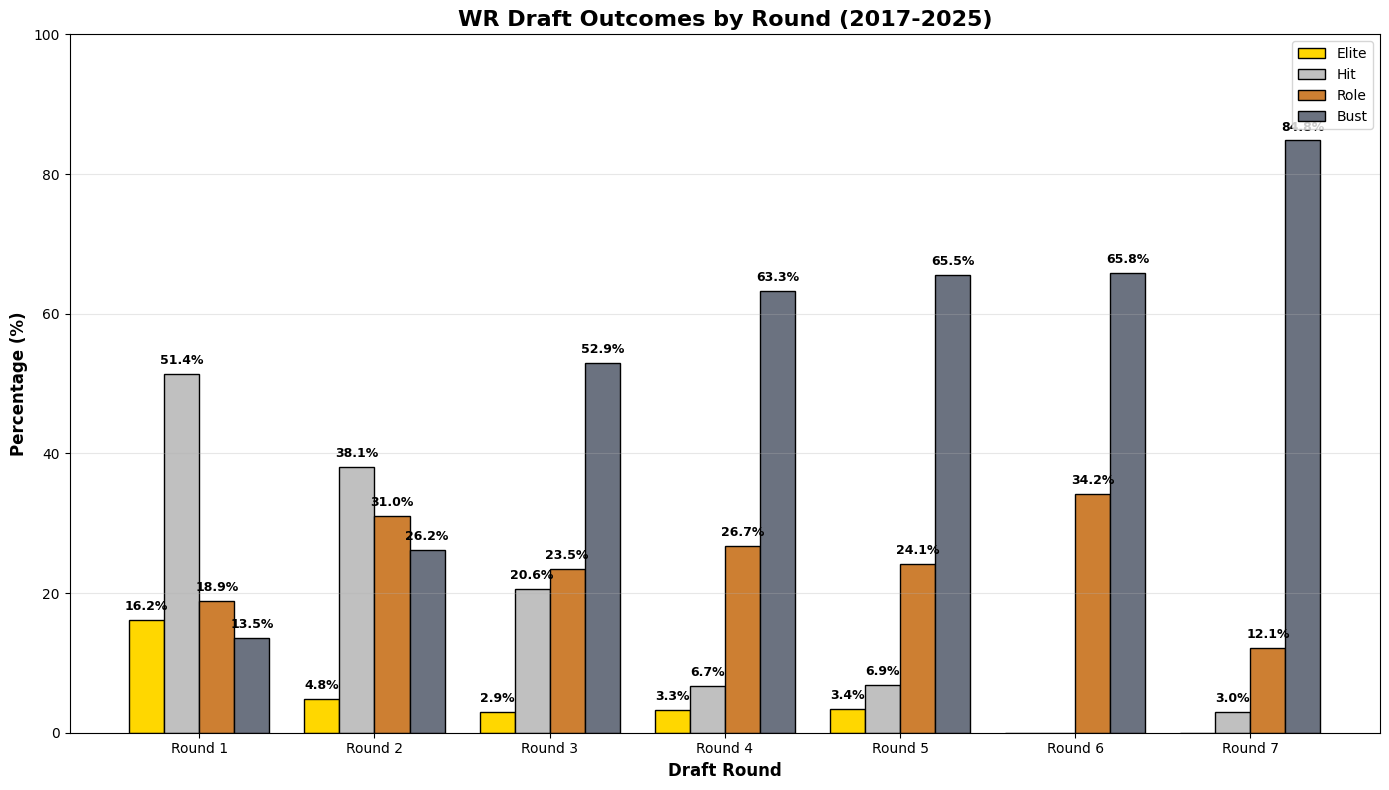


📋 RAW PERCENTAGES BY ROUND:
Round 1.0: Elite=16.2%, Hit=51.4%, Role=18.9%, Bust=13.5%
Round 2.0: Elite=4.8%, Hit=38.1%, Role=31.0%, Bust=26.2%
Round 3.0: Elite=2.9%, Hit=20.6%, Role=23.5%, Bust=52.9%
Round 4.0: Elite=3.3%, Hit=6.7%, Role=26.7%, Bust=63.3%
Round 5.0: Elite=3.4%, Hit=6.9%, Role=24.1%, Bust=65.5%
Round 6.0: Elite=0.0%, Hit=0.0%, Role=34.2%, Bust=65.8%
Round 7.0: Elite=0.0%, Hit=3.0%, Role=12.1%, Bust=84.8%


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Your results dataframe is already loaded from the previous cell
print("CREATING VISUALIZATION...")
print("=" * 60)

# Set up the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Get the data
rounds = results['Round']
elite = results['elite_rate']
hit = results['hit_rate']
role = results['role_rate']
bust = results['bust_rate']

# Set up bar positions
x = np.arange(len(rounds))
width = 0.2

# Create bars
bars1 = ax.bar(x - width*1.5, elite, width, label='Elite', color='#FFD700', edgecolor='black')
bars2 = ax.bar(x - width/2, hit, width, label='Hit', color='#C0C0C0', edgecolor='black')
bars3 = ax.bar(x + width/2, role, width, label='Role', color='#CD7F32', edgecolor='black')
bars4 = ax.bar(x + width*1.5, bust, width, label='Bust', color='#6B7280', edgecolor='black')

# Customize the chart
ax.set_xlabel('Draft Round', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('WR Draft Outcomes by Round (2017-2025)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Round {r}' for r in rounds])
ax.set_ylim(0, 100)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only label if bar has height
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('wr_draft_hit_rates.png', dpi=300, bbox_inches='tight')
plt.show()

# Also show the raw numbers for reference
print("\n📋 RAW PERCENTAGES BY ROUND:")
print("=" * 60)
for i, row in results.iterrows():
    print(f"Round {row['Round']}: Elite={row['elite_rate']}%, Hit={row['hit_rate']}%, Role={row['role_rate']}%, Bust={row['bust_rate']}%")



Now that we have the production based on draft position, I want to find why receivers get drafted where they do. The first step I want to take is seeing how college yards/game translates into average draft positon! Keep in mind, these stats are from the 300 top college football receiving yards season by year. So players who have seasons outside of the top 300 in terms of receiving yards will now show up.

In [15]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
    SELECT c.Player,
           SUM(c.G) AS games_played,
           d.Player AS overall_pick, 
           c.Year,
           AVG(c.RecYperG) AS YDSperGame
    FROM college c
    LEFT JOIN draft_picks d 
    ON   d.Name = c.Player
    WHERE d.Year BETWEEN 2017 AND 2025
    GROUP BY c.Player
    ORDER BY 3 
"""

# Execute and display
results = pd.read_sql_query(query, conn)

print("WR COLLEGE YPG BY DRAFT PICK (2017-2025)")
print("=" * 100)
print(results.to_string(index=False))

# Also show overall totals
print("\n" + "=" * 100)
print("OVERALL SUMMARY")

conn.close()

WR COLLEGE YPG BY DRAFT PICK (2017-2025)
                  Player  games_played  overall_pick  YEAR  YDSperGame
           Travis Hunter            22             2  2023   88.450000
           Ja'Marr Chase            14             5  2019  127.100000
           Jaylen Waddle            34             6  2018   66.033333
            Malik Nabers            38             6  2021   77.066667
            Drake London            27             8  2019   87.600000
       Tetairoa McMillan            37             8  2022   92.066667
             Rome Odunze            36             9  2021   83.600000
           DeVonta Smith            40            10  2018   96.300000
          Garrett Wilson            33            10  2019   72.500000
             Chris Olave            33            11  2019   80.900000
        Jameson Williams            15            12  2021  104.800000
             Jerry Jeudy            28            15  2018   88.600000
            Jahan Dotson            

Now that we have this information, I want to know how many players with x ypg get drafted in each position as mentioned below:

Bucket:         Pick Range: 
Premium         1-10
Round 1         11-32
Round 2         33-64
Round 3         65-96
Round 4         97-128
Round 5-7       129+

My yards per game buckets will be as follows:
0-30 YPG
30-50 YPG
50-70 YPG
70-90 YPG
90+ YPG

In [6]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_avg_ypg AS (
    SELECT 
        c.Player,
        d.Player as Pick,
        d.Round,
        AVG(c.RecYperG) AS avg_ypg
    FROM college c
    LEFT JOIN draft_picks d ON d.Name = c.Player
    WHERE d.Year BETWEEN 2017 AND 2025
    GROUP BY c.Player
),
player_with_buckets AS(
    SELECT Player,
           Pick,
           Round,
           avg_ypg,
           CASE
                WHEN Pick <= 10 THEN '1-10 (Premium)'
                WHEN Pick <= 32 THEN '11-32 (Round 1)'
                WHEN Pick <= 64 THEN '33-64 (Round 2)'
                WHEN Pick <= 96 THEN '65-96 (Round 3)'
                WHEN Pick <= 128 THEN '97-128 (Round 4)'
                ELSE '129+ (Round 5-7)'
           END AS pick_range,
           CASE 
                WHEN avg_ypg < 30 THEN '0-30 YPG'
                WHEN avg_ypg < 50 THEN '30-50 YPG'
                WHEN avg_ypg < 70 THEN '50-70 YPG'
                WHEN avg_ypg < 90 THEN '70-90 YPG'
                ELSE '90+ YPG'
           END as ypg_range
    FROM player_avg_ypg
)
SELECT pick_range, 
       ypg_range, 
       COUNT(*) as player_count
FROM player_with_buckets
GROUP BY pick_range, ypg_range
ORDER BY pick_range, ypg_range
"""



# Execute and display
results = pd.read_sql_query(query, conn)

print("WR COLLEGE YPG BY DRAFT PICK (2017-2025)")
print("=" * 100)
print(results.to_string(index=False))

# Also show overall totals
print("\n" + "=" * 100)
print("OVERALL SUMMARY")

conn.close()

WR COLLEGE YPG BY DRAFT PICK (2017-2025)
      pick_range ypg_range  player_count
  1-10 (Premium) 50-70 YPG             1
  1-10 (Premium) 70-90 YPG             5
  1-10 (Premium)   90+ YPG             3
 11-32 (Round 1) 50-70 YPG             7
 11-32 (Round 1) 70-90 YPG            14
 11-32 (Round 1)   90+ YPG             3
129+ (Round 5-7) 30-50 YPG            21
129+ (Round 5-7) 50-70 YPG            40
129+ (Round 5-7) 70-90 YPG            31
129+ (Round 5-7)   90+ YPG             9
 33-64 (Round 2) 30-50 YPG             4
 33-64 (Round 2) 50-70 YPG            14
 33-64 (Round 2) 70-90 YPG            13
 33-64 (Round 2)   90+ YPG             6
 65-96 (Round 3) 30-50 YPG             6
 65-96 (Round 3) 50-70 YPG            11
 65-96 (Round 3) 70-90 YPG             8
 65-96 (Round 3)   90+ YPG             4
97-128 (Round 4) 30-50 YPG             3
97-128 (Round 4) 50-70 YPG             8
97-128 (Round 4) 70-90 YPG             9
97-128 (Round 4)   90+ YPG             2

OVERALL SUMMARY

📊 CREATING VISUALIZATION...


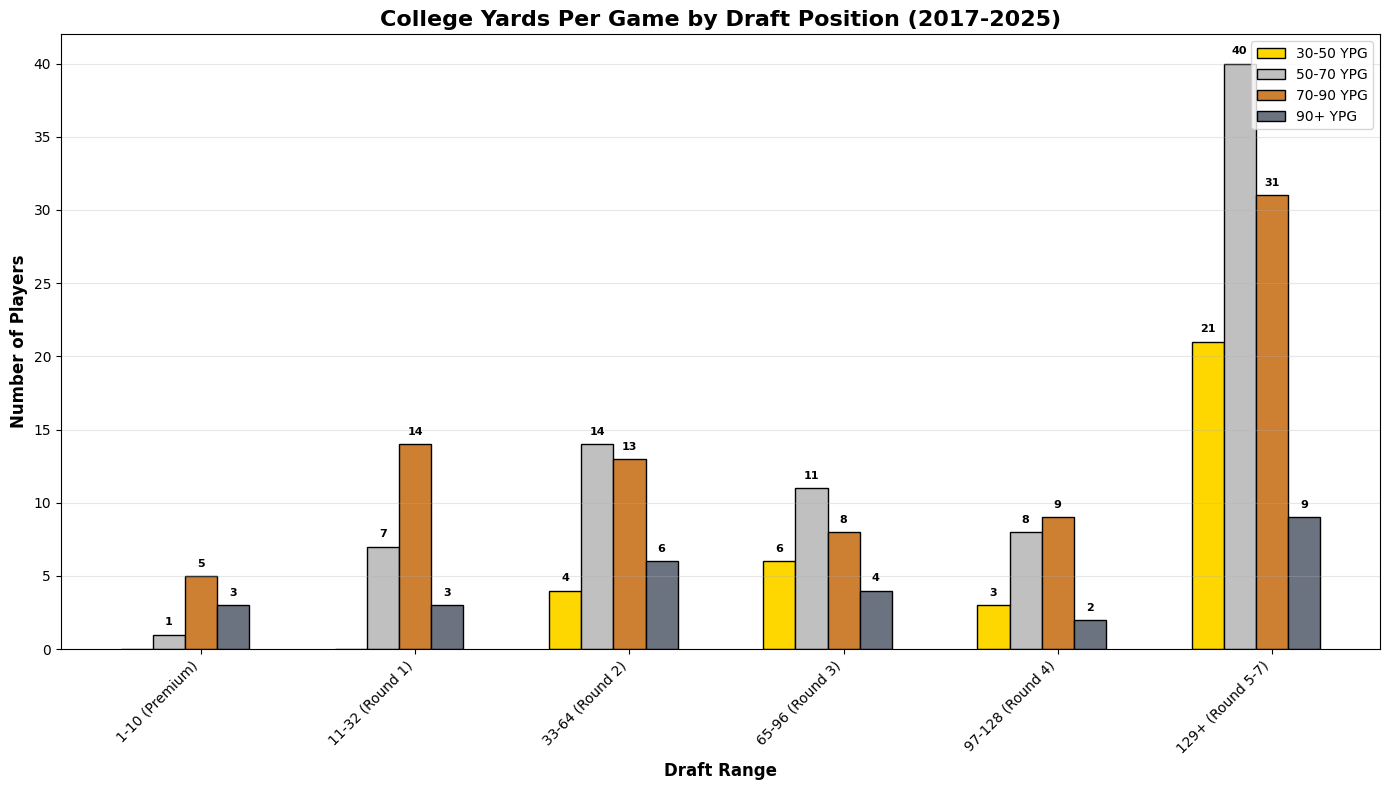


📋 RAW NUMBERS BY DRAFT RANGE:
ypg_range         30-50 YPG  50-70 YPG  70-90 YPG  90+ YPG
pick_range                                                
1-10 (Premium)          0.0        1.0        5.0      3.0
11-32 (Round 1)         0.0        7.0       14.0      3.0
33-64 (Round 2)         4.0       14.0       13.0      6.0
65-96 (Round 3)         6.0       11.0        8.0      4.0
97-128 (Round 4)        3.0        8.0        9.0      2.0
129+ (Round 5-7)       21.0       40.0       31.0      9.0


In [7]:
import matplotlib.pyplot as plt
import numpy as np

print("📊 CREATING VISUALIZATION...")
print("=" * 60)

# First, let's pivot the data to get it in the right format
pivot_data = results.pivot(index='pick_range', columns='ypg_range', values='player_count').fillna(0)

# Define the order for pick ranges
pick_order = ['1-10 (Premium)', '11-32 (Round 1)', '33-64 (Round 2)', 
              '65-96 (Round 3)', '97-128 (Round 4)', '129+ (Round 5-7)']
ypg_order = ['30-50 YPG', '50-70 YPG', '70-90 YPG', '90+ YPG']

# Reindex to ensure correct order
pivot_data = pivot_data.reindex(index=pick_order, columns=ypg_order)

# Set up the plot
fig, ax = plt.subplots(figsize=(14, 8))

# Set up bar positions
x = np.arange(len(pick_order))
width = 0.15  # Slightly smaller to fit 5 bars

# Colors for each YPG range
colors = ['#FFD700', '#C0C0C0', '#CD7F32', '#6B7280', '#2E4057']

# Create bars for each YPG range
bars = []
for i, ypg in enumerate(ypg_order):
    bar = ax.bar(x + (i - 2) * width, pivot_data[ypg].values, width, 
                 label=ypg, color=colors[i], edgecolor='black')
    bars.append(bar)

# Customize the chart
ax.set_xlabel('Draft Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Players', fontsize=12, fontweight='bold')
ax.set_title('College Yards Per Game by Draft Position (2017-2025)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pick_order, rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{int(height)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('college_ypg_by_draft_range.png', dpi=300, bbox_inches='tight')
plt.show()

# Show the raw data
print("\n📋 RAW NUMBERS BY DRAFT RANGE:")
print("=" * 60)
print(pivot_data.to_string())

This data shows us almost nothing, which in it of itself shows us something! There is not strong correlation to YPG and pick range, meaning that this stat isn't a strong predictor of where a receiver is going to be picked in the draft. Therefore, if there is a player who a team has their eyes set on who didn't have great production in yardage, you can't bank on them being avaialble in later rounds. 


We have to find what is a good indicator of draft position! So for this, I first need to make a query to find multiple statistics from college receivers:

YPG
YPC
MAX REC TD
40 Time
Overall Pick

In [20]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_data AS (
    SELECT 
        c.Player,
        c.Conf,
        AVG(c.RecYperG) as college_ypg,
        AVG(c.YperR) as yards_per_catch,
        MAX(c.RecTD) as peak_td,
        com.`40yd` as forty_time,
        d.Player AS Pick,
        d.Year as draft_year,
        CASE 
            WHEN c.Conf IN ('SEC', 'Big Ten') THEN 'SEC, BIG 10'
            WHEN c.Conf IN ('ACC', 'Big 12', 'Pac-12') THEN 'ACC, BIG 12, PAC 12'
            ELSE 'Other'
        END as conference_tier
    FROM college c
    LEFT JOIN draft_picks d ON d.Name = c.Player
    LEFT JOIN combine com ON com.Player = c.Player
    WHERE d.Year BETWEEN 2017 AND 2025
        AND com.`40yd` IS NOT NULL  -- Only players with 40 time
        AND com.`40yd` > 0
    GROUP BY c.Player
)
SELECT * FROM player_data
ORDER BY Pick;
"""



# Execute and display
player_data = pd.read_sql_query(query, conn)

print("WR COLLEGE STATS AND PICKS (2017-2025)")
print("=" * 100)
print(player_data.to_string(index=False))


conn.close()

WR COLLEGE STATS AND PICKS (2017-2025)
                  Player     Conf  college_ypg  yards_per_catch  peak_td  forty_time  Pick  draft_year     conference_tier
           Ja'Marr Chase      SEC   127.100000        21.200000       20        4.34     5        2021         SEC, BIG 10
             Rome Odunze   Pac-12    83.600000        14.400000       13        4.45     9        2024 ACC, BIG 12, PAC 12
          Garrett Wilson  Big Ten    72.500000        15.433333       12        4.38    10        2022         SEC, BIG 10
             Chris Olave  Big Ten    80.900000        15.433333       13        4.39    11        2022         SEC, BIG 10
             Jerry Jeudy      SEC    88.600000        17.200000       14        4.45    15        2020         SEC, BIG 10
            Jahan Dotson  Big Ten    78.066667        16.033333       12        4.43    16        2022         SEC, BIG 10
             CeeDee Lamb   Big 12    80.800000        18.900000       14        4.50    17        20

Now we need to plot it on a scatter plot to see what we can find!

CREATING SCATTER PLOT: COLLEGE PRODUCTION vs 40 TIME
Total players with data: 167
Pick range: 5 to 258



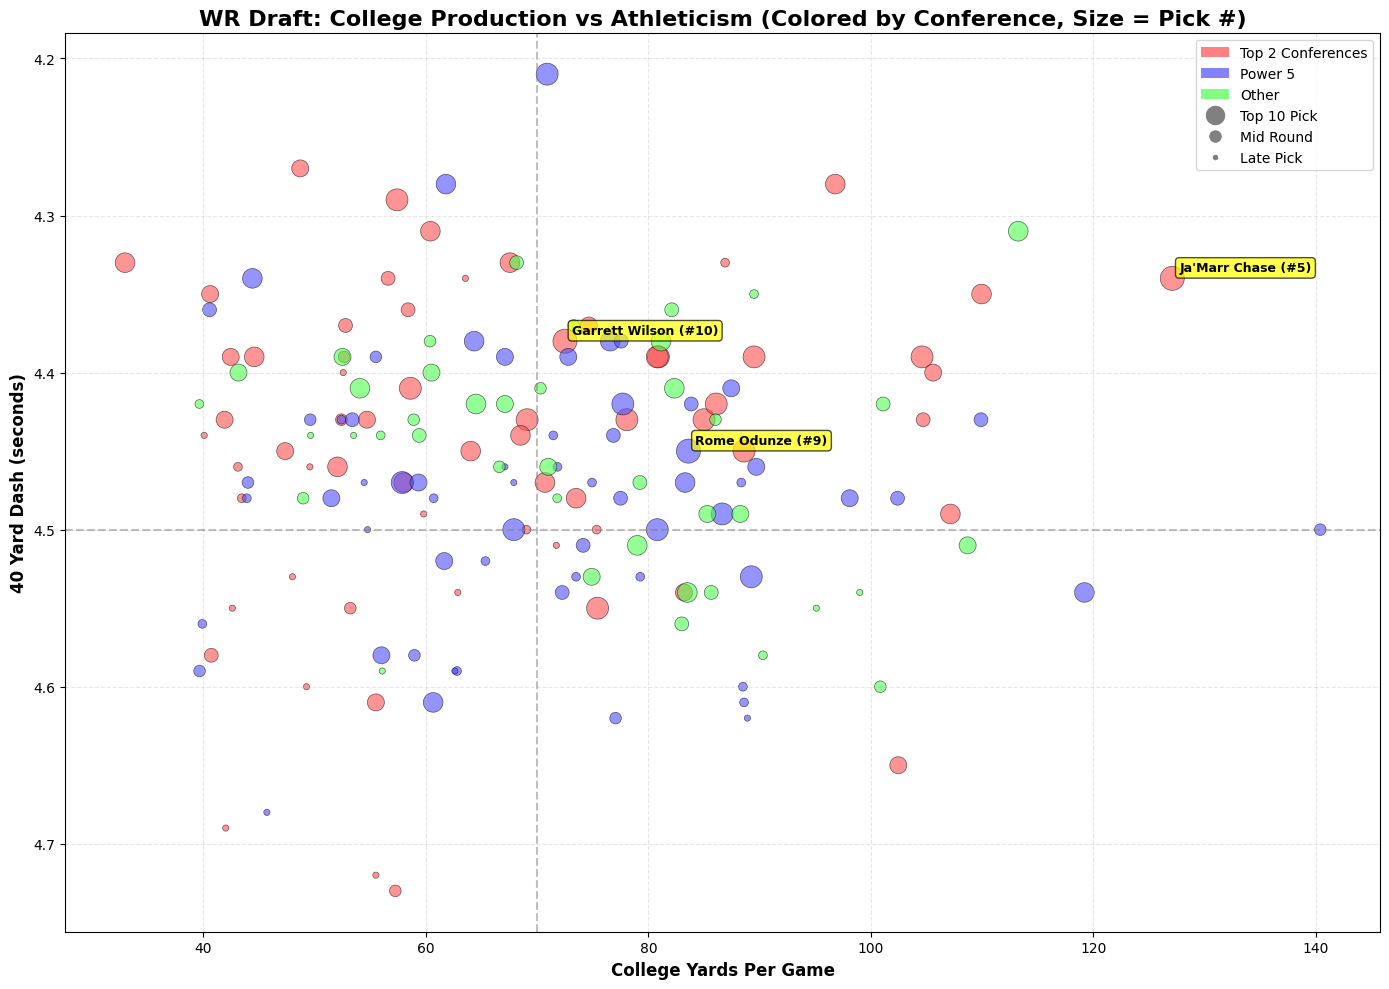


📊 SUMMARY BY CONFERENCE TIER:
                     Count  Avg YPG  Avg 40 Time  Avg Pick
conference_tier                                           
ACC, BIG 12, PAC 12     62    71.05         4.48    128.21
Other                   41    73.99         4.45    134.37
SEC, BIG 10             64    66.27         4.45    106.92

✅ Visualization saved as 'wr_draft_scatter_by_pick.png'


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def get_marker_size(pick):
    # BASED ON ROUNDS LAST YEAR
    if pick <= 10:
        return 300  # Top 10: huge
    elif pick <= 32:
        return 250  # Round 1: big
    elif pick <= 64:
        return 200  # Round 2: medium-large
    elif pick <= 102:
        return 150  # Round 3: medium
    elif pick <= 138:
        return 100   # Round 4: small
    elif pick <= 176:
        return 70   # Round 5: small
    elif pick <= 216:
        return 40   # Round 6: small
    else:
        return 20   # Round 7: tiny


print("CREATING SCATTER PLOT: COLLEGE PRODUCTION vs 40 TIME")
print("=" * 60)

# First, let's check what's in player_data
print(f"Total players with data: {len(player_data)}")
print(f"Pick range: {player_data['Pick'].min()} to {player_data['Pick'].max()}")
print("\n" + "=" * 60)

# Set up the plot
fig, ax = plt.subplots(figsize=(14, 10))

# Define colors for conference tiers
conference_colors = {
    'SEC, BIG 10': '#FF4D4D',         # Red
    'ACC, BIG 12, PAC 12': '#4D4DFF', # Blue
    'Other': '#4DFF4D'                # Green
}

# Define marker sizes based on pick number (lower pick = bigger marker)
# Pick 1 = size 300, Pick 300 = size 30
max_pick = player_data['Pick'].max()
player_data['marker_size'] = player_data['Pick'].apply(get_marker_size)

# Create scatter plot for each conference tier
for tier, color in conference_colors.items():
    tier_data = player_data[player_data['conference_tier'] == tier]
    
    if len(tier_data) > 0:
        scatter = ax.scatter(
            tier_data['college_ypg'], 
            tier_data['forty_time'],
            s=tier_data['marker_size'],  # Size by pick number
            c=color,
            alpha=0.6,
            edgecolors='black',
            linewidth=0.5,
            label=f"{tier} ({len(tier_data)} players)"
        )

# Add labels for top 10 picks
top_picks = player_data[player_data['Pick'] <= 10]
for _, player in top_picks.iterrows():
    ax.annotate(
        f"{player['Player']} (#{player['Pick']})",
        (player['college_ypg'], player['forty_time']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7)
    )

# Add a colorbar to explain marker sizes
# Create a legend for pick ranges
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#FF4D4D', alpha=0.7, label='Top 2 Conferences'),
    Patch(facecolor='#4D4DFF', alpha=0.7, label='Power 5'),
    Patch(facecolor='#4DFF4D', alpha=0.7, label='Other'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=15, label='Top 10 Pick'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Mid Round'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=5, label='Late Pick')
]

# Customize the chart
ax.set_xlabel('College Yards Per Game', fontsize=12, fontweight='bold')
ax.set_ylabel('40 Yard Dash (seconds)', fontsize=12, fontweight='bold')
ax.set_title('WR Draft: College Production vs Athleticism (Colored by Conference, Size = Pick #)', 
             fontsize=16, fontweight='bold')

# Invert y-axis (lower 40 time is better)
ax.invert_yaxis()

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# Add some reference lines (optional)
ax.axhline(y=4.5, color='gray', linestyle='--', alpha=0.5, label='4.5 sec threshold')
ax.axvline(x=70, color='gray', linestyle='--', alpha=0.5, label='70 YPG threshold')

plt.tight_layout()
plt.savefig('wr_draft_scatter_by_pick.png', dpi=300, bbox_inches='tight')
plt.show()

# Show summary statistics
print("\n📊 SUMMARY BY CONFERENCE TIER:")
print("=" * 60)
summary = player_data.groupby('conference_tier').agg({
    'Player': 'count',
    'college_ypg': 'mean',
    'forty_time': 'mean',
    'Pick': 'mean'
}).round(2)
summary.columns = ['Count', 'Avg YPG', 'Avg 40 Time', 'Avg Pick']
print(summary.to_string())

print("\n✅ Visualization saved as 'wr_draft_scatter_by_pick.png'")

PRACTICE PLOT

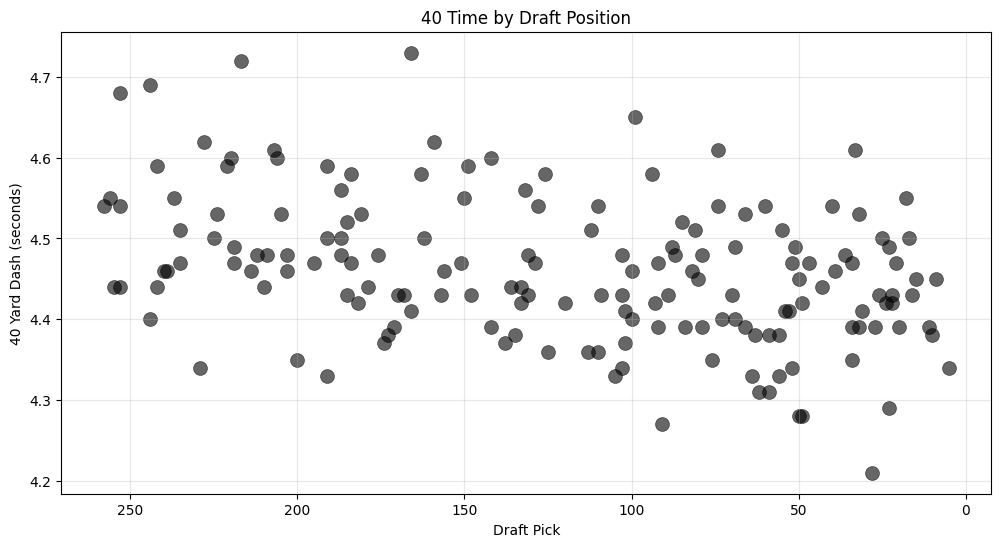

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure
fig, ax = plt.subplots(figsize=(12, 6))

# Your scatter plot here!
# Hint: ax.scatter(X_DATA, Y_DATA, color='blue', alpha=0.6)
ax.scatter(
    player_data['Pick'],
    player_data['forty_time'],
    s=100,  # Size by pick number
    c='black',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5,
    label=f"ALL PLAYERS"
)

# Customize
ax.set_xlabel('Draft Pick')
ax.set_ylabel('40 Yard Dash (seconds)')
ax.set_title('40 Time by Draft Position')
ax.invert_xaxis()  # This puts pick #1 on the left
ax.grid(True, alpha=0.3)

# Add reference line (bonus)
# ax.axhline(y=4.5, color='red', linestyle='--', alpha=0.7)

plt.show()